# 🏡 Week 2 – Classification Models

### SkillNexis Machine Learning & AI Internship

---

## Objectives

This notebook demonstrates:

- Building a Linear Regression model for House Price Prediction
- Training a Logistic Regression model on the Titanic dataset
- Comparing Decision Tree and KNN classifiers
- Evaluating models using Accuracy Score, Confusion Matrix, and R² Score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    r2_score,
    mean_squared_error
)

from sklearn.preprocessing import LabelEncoder

## Assignment 1 - House Price Prediction using Linear Regression

In [3]:
house_df = pd.read_csv("Housing.csv")

print("Housing Dataset Loaded Successfully!")


Housing Dataset Loaded Successfully!


## Explore the Housing Dataset

In [5]:
house_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
house_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Data Preprocessing

In [8]:
# Check missing values

house_df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [9]:
# Encode categorical columns

label_encoder = LabelEncoder()

categorical_columns = house_df.select_dtypes(include="object").columns

for column in categorical_columns:
    house_df[column] = label_encoder.fit_transform(house_df[column])

house_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## Train-Test Split

In [10]:
X = house_df.drop("price", axis=1)

y = house_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

In [13]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
predictions = linear_model.predict(X_test)

## Model Evaluation

In [14]:
print("R² Score :", r2_score(y_test, predictions))

print("Mean Squared Error :", mean_squared_error(y_test, predictions))

R² Score : 0.6494754192267803
Mean Squared Error : 1771751116594.0352


## Actual vs Predicted House Prices

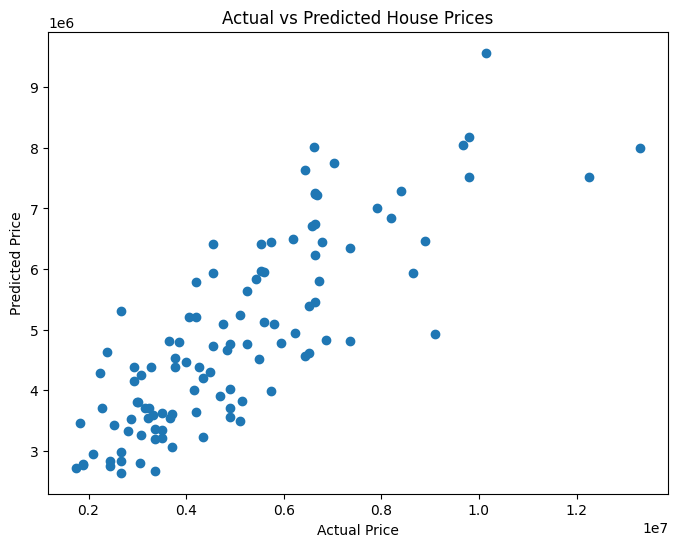

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Observation

The Linear Regression model predicts house prices based on the available features. The R² Score indicates how well the model explains the variation in house prices, while the scatter plot compares actual prices with predicted prices.

# Assignment 2 - Titanic Survival Prediction using Logistic Regression

In [16]:
titanic_df = pd.read_csv("cleaned_titanic.csv")

print("Titanic Dataset Loaded Successfully!")

Titanic Dataset Loaded Successfully!


In [17]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,False,True


In [18]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked_Q   891 non-null    bool   
 12  Embarked_S   891 non-null    bool   
dtypes: bool(2), float64(2), int64(6), object(3)
memory usage: 78.4+ KB


## Prepare the Dataset

In [19]:
# Encode remaining categorical columns (if any)

label_encoder = LabelEncoder()

categorical_columns = titanic_df.select_dtypes(include="object").columns

for column in categorical_columns:
    titanic_df[column] = label_encoder.fit_transform(titanic_df[column])

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,108,1,22.0,1,0,523,7.2500,147,False,True
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,False,False
2,3,1,3,353,0,26.0,0,0,669,7.9250,147,False,True
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,False,True
4,5,0,3,15,1,35.0,0,0,472,8.0500,147,False,True


## Train-Test Split

In [20]:
X = titanic_df.drop("Survived", axis=1)

y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Logistic Regression Model

In [21]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [22]:
logistic_predictions = logistic_model.predict(X_test)

## Model Evaluation

In [23]:
accuracy = accuracy_score(y_test, logistic_predictions)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.8100558659217877


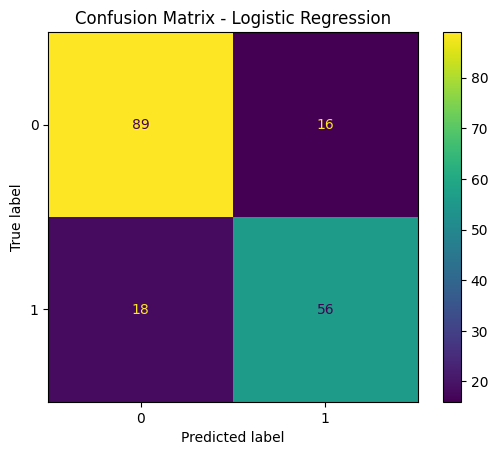

In [24]:
cm = confusion_matrix(y_test, logistic_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Observation

The Logistic Regression model predicts passenger survival based on the available features. The confusion matrix and accuracy score help evaluate the model's classification performance.

# Practice Question 3 - Decision Tree Classifier

In [25]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.7821229050279329


# Practice Question 4 - K-Nearest Neighbors (KNN) Classifier

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_predictions = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.6703910614525139


In [ ]:
## Compare Model Accuracy

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        knn_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
2,K-Nearest Neighbors,0.670391


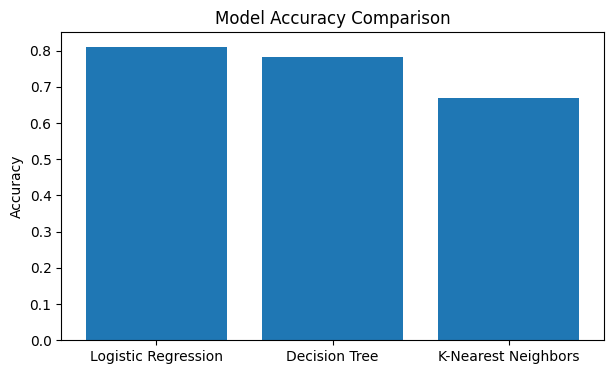

In [28]:
plt.figure(figsize=(7,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()


# Practice Question 5 - Tune max_depth of Decision Tree

In [30]:
depths = [3, 5, 7, 10]

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    score = accuracy_score(y_test, prediction)

    print(f"max_depth = {depth} --> Accuracy = {score:.4f}")

max_depth = 3 --> Accuracy = 0.7989
max_depth = 5 --> Accuracy = 0.7542
max_depth = 7 --> Accuracy = 0.8324
max_depth = 10 --> Accuracy = 0.8045


## Observation

Changing the value of **max_depth** affects the performance of the Decision Tree model. A very small depth may underfit the data, while a very large depth may overfit. An appropriate value provides better prediction accuracy.

# Conclusion

In this notebook:

- Built a Linear Regression model for house price prediction.
- Trained a Logistic Regression model for Titanic survival prediction.
- Evaluated Logistic Regression using Accuracy Score and Confusion Matrix.
- Compared Decision Tree and KNN classifiers.
- Tuned the `max_depth` parameter of the Decision Tree.

This notebook fulfills the Week 2 assignment requirements of the SkillNexis Machine Learning & AI Internship.